In [75]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import yfinance as yf

# Stock History Diagram

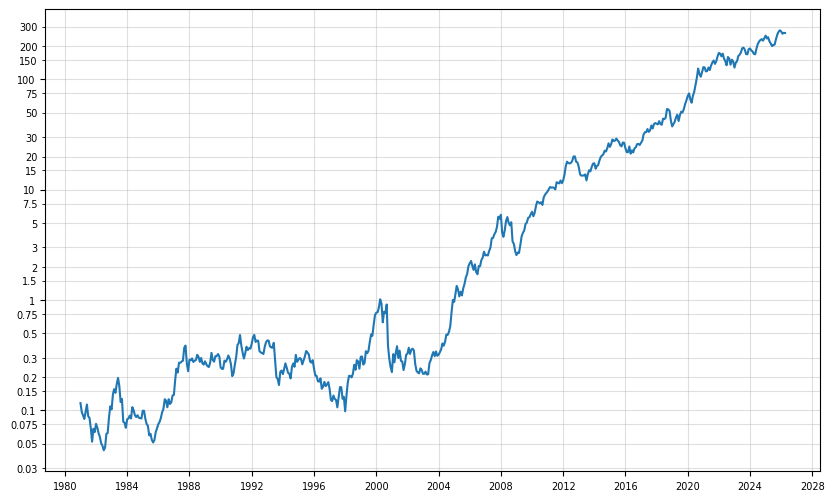

In [106]:
# get/set data
stock_ticker = "AAPL"
stock = yf.Ticker(stock_ticker)
per = "max"

history_length = stock.history(period=per)

# resampling (data points for end of month)
end_of_month_closing = history_length["Close"].resample("ME").last()
closing_list = end_of_month_closing.to_list()
dates = end_of_month_closing.index

# setting up the plot
plt.figure(figsize=(10, 6))
plt.semilogy(dates, closing_list)

ax = plt.gca()

# x-axis spacing
ax.xaxis.set_major_locator(mdates.YearLocator(base=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# y-axis formating
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%g'))
ax.yaxis.set_minor_formatter(ticker.FormatStrFormatter('%g')) # %g shows float numbers (no rounding up)

# set y-axis spacing
ax.yaxis.set_major_locator(ticker.LogLocator(base=10, subs=(1,))) 
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10, subs=(1, 1.5, 2, 3, 5, 7.5)))

# set font size (smaller for less crossovers)
ax.tick_params(axis='y', which='both', labelsize=7)
ax.tick_params(axis='x', which='both', labelsize=7)

# find value of data points faster with a grid
plt.grid(True, which="both", ls="-", alpha=0.4)

plt.show()